In [17]:
import os
os.environ["MLFLOW_ALLOW_FILE_STORE"] = "true"

import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import root_mean_squared_error, mean_absolute_error, r2_score
import xgboost as xgb
import mlflow
import mlflow.xgboost
import matplotlib.pyplot as plt

In [2]:
# 1. Veriyi Okuma ve Sütun Tanımları
index_columns = ['unit_number', 'time_in_cycles']
setting_columns = ['setting_1', 'setting_2', 'setting_3']
sensor_columns = [f'sensor_{i}' for i in range(1, 22)]
columns = index_columns + setting_columns + sensor_columns

train_df = pd.read_csv('../data/raw/train_FD001.txt', sep=r'\s+', header=None, names=columns)

In [3]:
# 2. RUL ve Kırpma (Piecewise Linear - 125 tavan)
max_cycle_df = train_df.groupby('unit_number')['time_in_cycles'].max().reset_index()
max_cycle_df.columns = ['unit_number', 'max_cycle']
train_df = train_df.merge(max_cycle_df, on='unit_number', how='left')
train_df['RUL'] = train_df['max_cycle'] - train_df['time_in_cycles']
MAX_RUL = 125
train_df['RUL_clipped'] = train_df['RUL'].clip(upper=MAX_RUL)

In [4]:
# 3. Bilgi taşımayan sabit sütunların filtrelenmesi
constant_features = [
    'sensor_1', 'sensor_5', 'sensor_6', 'sensor_10', 
    'sensor_16', 'sensor_18', 'sensor_19', 'setting_3'
]
informative_sensors = [
    col for col in (setting_columns + sensor_columns) 
    if col not in constant_features
]

In [7]:
# 4. Kayan Pencere Özelliklerini Türeten Fonksiyon
def add_rolling_features(df, sensor_list, window_size=5):
    """
    Her motor için bağımsız olarak hareketli ortalama (mean) ve
    standart sapma (std) türetir.
    """
    df_feat = df.copy()
    
    # Motor bazında kayan ortalama
    rolled_mean = (
        df_feat.groupby('unit_number')[sensor_list]
        .rolling(window=window_size, min_periods=1)
        .mean()
        .reset_index(level=0, drop=True)
    )
    rolled_mean.columns = [f'{col}_roll_mean_{window_size}' for col in sensor_list]
    
    # Motor bazında kayan standart sapma (ilk döngü için 0 doldurulur)
    rolled_std = (
        df_feat.groupby('unit_number')[sensor_list]
        .rolling(window=window_size, min_periods=1)
        .std()
        .reset_index(level=0, drop=True)
        .fillna(0)
    )
    rolled_std.columns = [f'{col}_roll_std_{window_size}' for col in sensor_list]
    
    # Yeni sütunları ana tabloya bağla
    return pd.concat([df_feat, rolled_mean, rolled_std], axis=1)

In [8]:
# 5 döngülük pencere ile özellikleri türetelim
featured_df = add_rolling_features(train_df, informative_sensors, window_size=5)

print(f"Orijinal sütun sayısı: {train_df.shape[1]}")
print(f"Yeni özelliklerle sütun sayısı: {featured_df.shape[1]}")

Orijinal sütun sayısı: 29
Yeni özelliklerle sütun sayısı: 61


In [9]:
#Şimdi veri sızıntısını önlemek için aynı motor bazlı ayrımı uygulayacağız. Böylece doğrulama kümesi Baseline modelimizle birebir aynı kalacak ve metrik farkı tamamen yeni özellikler ile XGBoost'un etkisini yansıtacak.

In [13]:
# 1. Asimetrik PHM skor fonksiyonunu tanımlayalım
def compute_phm_score(y_true, y_pred):
    d = np.array(y_pred) - np.array(y_true)
    scores = np.where(d < 0, np.exp(-d / 13.0) - 1.0, np.exp(d / 10.0) - 1.0)
    return float(np.sum(scores))

In [14]:
# 2. Motor bazlı Train / Validation ayrımı (Baseline ile birebir aynı 80/20 dağılım)
unique_units = featured_df['unit_number'].unique()
train_units, val_units = train_test_split(unique_units, test_size=0.20, random_state=42)

train_data = featured_df[featured_df['unit_number'].isin(train_units)].copy()
val_data = featured_df[featured_df['unit_number'].isin(val_units)].copy()

In [15]:
# 3. Girdi matrislerinin (X) ve hedef vektörlerin (y) hazırlanması
metadata_and_target = ['unit_number', 'max_cycle', 'RUL', 'RUL_clipped']
feature_cols = [
    col for col in featured_df.columns 
    if col not in constant_features and col not in metadata_and_target
]

X_train = train_data[feature_cols]
y_train = train_data['RUL_clipped']

X_val = val_data[feature_cols]
y_val = val_data['RUL_clipped']

print(f"Eğitimde kullanılacak özellik sayısı: {len(feature_cols)}")

Eğitimde kullanılacak özellik sayısı: 49


In [16]:
# 4. MLflow Deneyi ve XGBoost Eğitimi
mlflow.set_tracking_uri("file:../mlruns")
mlflow.set_experiment("turbofan-rul-advanced")

xgb_params = {
    "n_estimators": 150,
    "learning_rate": 0.05,
    "max_depth": 5,
    "subsample": 0.8,
    "colsample_bytree": 0.8,
    "random_state": 42
}

with mlflow.start_run(run_name="xgboost_rolling_window_5"):
    # Ağaç tabanlı model olduğu için StandardScaler gerekmez
    model = xgb.XGBRegressor(**xgb_params)
    model.fit(X_train, y_train)
    
    # Tahminler
    y_train_pred = model.predict(X_train)
    y_val_pred = model.predict(X_val)
    
    # Metrikler
    train_rmse = root_mean_squared_error(y_train, y_train_pred)
    val_rmse = root_mean_squared_error(y_val, y_val_pred)
    val_mae = mean_absolute_error(y_val, y_val_pred)
    val_r2 = r2_score(y_val, y_val_pred)
    train_phm = compute_phm_score(y_train, y_train_pred)
    val_phm = compute_phm_score(y_val, y_val_pred)
    
    # MLflow loglama
    mlflow.log_params(xgb_params)
    mlflow.log_param("window_size", 5)
    mlflow.log_param("feature_count", len(feature_cols))
    mlflow.log_param("features", "raw_plus_rolling_mean_std")
    
    mlflow.log_metric("train_rmse", train_rmse)
    mlflow.log_metric("val_rmse", val_rmse)
    mlflow.log_metric("val_mae", val_mae)
    mlflow.log_metric("val_r2", val_r2)
    mlflow.log_metric("train_phm_score", train_phm)
    mlflow.log_metric("val_phm_score", val_phm)
    
    mlflow.xgboost.log_model(model, name="model")
    
    print("\n--- XGBoost (Rolling Features) Sonuçları ---")
    print(f"Val RMSE:      {val_rmse:.2f}  (Baseline: 17.93)")
    print(f"Val MAE:       {val_mae:.2f}  (Baseline: 14.53)")
    print(f"Val R²:        {val_r2:.4f}  (Baseline: 0.8152)")
    print(f"Val PHM Score: {val_phm:,.2f}  (Baseline: 21,964.17)")

2026/09/02 12:00:01 INFO mlflow.tracking.fluent: Experiment with name 'turbofan-rul-advanced' does not exist. Creating a new experiment.



--- XGBoost (Rolling Features) Sonuçları ---
Val RMSE:      14.85  (Baseline: 17.93)
Val MAE:       10.01  (Baseline: 14.53)
Val R²:        0.8732  (Baseline: 0.8152)
Val PHM Score: 17,500.92  (Baseline: 21,964.17)


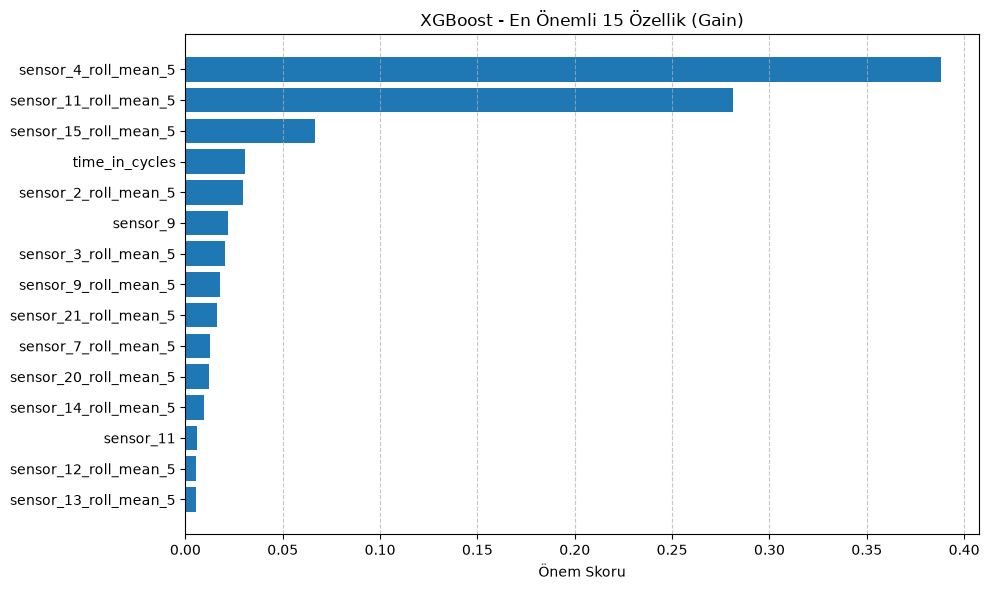


En Etkili İlk 5 Özellik:
              feature  importance
 sensor_4_roll_mean_5    0.388134
sensor_11_roll_mean_5    0.281309
sensor_15_roll_mean_5    0.066485
       time_in_cycles    0.030747
 sensor_2_roll_mean_5    0.029402


In [18]:
# En önemli ilk 15 özelliği görselleştirme
importance_df = pd.DataFrame({
    'feature': feature_cols,
    'importance': model.feature_importances_
}).sort_values('importance', ascending=False)

plt.figure(figsize=(10, 6))
plt.barh(importance_df['feature'][:15][::-1], importance_df['importance'][:15][::-1])
plt.title("XGBoost - En Önemli 15 Özellik (Gain)")
plt.xlabel("Önem Skoru")
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

print("\nEn Etkili İlk 5 Özellik:")
print(importance_df.head(5).to_string(index=False))

In [19]:
# 1. Kayan ortalama
rm_20 = (
    featured_df.groupby('unit_number')[informative_sensors]
    .rolling(window=20, min_periods=1)
    .mean()
    .reset_index(level=0, drop=True)
)
rm_20.columns = [f'{col}_roll_mean_20' for col in informative_sensors]

# 2. Delta (Anlık Sensör Değeri - 20 Döngülük Trend)
deltas = pd.DataFrame(
    featured_df[informative_sensors].values - rm_20.values,
    columns=[f'{col}_delta_20' for col in informative_sensors],
    index=featured_df.index
)

# 3. Tabloyu güncelle
featured_df = pd.concat([featured_df, rm_20, deltas], axis=1)
print(f"Toplam sütun sayısı: {featured_df.shape[1]}")

Toplam sütun sayısı: 93


In [20]:
# Yeni özellik listesi ve matrisler
feature_cols = [c for c in featured_df.columns if c not in constant_features + metadata_and_target]

X_train = featured_df[featured_df['unit_number'].isin(train_units)][feature_cols]
y_train = featured_df[featured_df['unit_number'].isin(train_units)]['RUL_clipped']

X_val = featured_df[featured_df['unit_number'].isin(val_units)][feature_cols]
y_val = featured_df[featured_df['unit_number'].isin(val_units)]['RUL_clipped']

# Eğit ve Tahmin Et
adv_model = xgb.XGBRegressor(**xgb_params)
adv_model.fit(X_train, y_train)

y_val_pred = adv_model.predict(X_val)

print(f"Val RMSE:      {root_mean_squared_error(y_val, y_val_pred):.2f} (Önceki XGB: 14.85)")
print(f"Val MAE:       {mean_absolute_error(y_val, y_val_pred):.2f} (Önceki XGB: 10.01)")
print(f"Val R²:        {r2_score(y_val, y_val_pred):.4f} (Önceki XGB: 0.8732)")
print(f"Val PHM Score: {compute_phm_score(y_val, y_val_pred):,.2f} (Önceki XGB: 17,500.92)")

Val RMSE:      14.47 (Önceki XGB: 14.85)
Val MAE:       9.77 (Önceki XGB: 10.01)
Val R²:        0.8796 (Önceki XGB: 0.8732)
Val PHM Score: 17,322.96 (Önceki XGB: 17,500.92)


In [21]:
# 1. Test verilerini ve gerçek RUL etiketlerini okuma
test_df = pd.read_csv('../data/raw/test_FD001.txt', sep=r'\s+', header=None, names=columns)
true_rul_df = pd.read_csv('../data/raw/RUL_FD001.txt', sep=r'\s+', header=None, names=['true_rul'])
y_test = true_rul_df['true_rul'].clip(upper=MAX_RUL).values

In [23]:
# 2. Test verisi için aynı özellik mühendisliği (5 ve 20 pencereleri)
# 5 döngülük pencereler
test_feat = add_rolling_features(test_df, informative_sensors, window_size=5)

# 20 döngülük ortalama ve delta
test_rm_20 = (
    test_feat.groupby('unit_number')[informative_sensors]
    .rolling(window=20, min_periods=1)
    .mean()
    .reset_index(level=0, drop=True)
)
test_rm_20.columns = [f'{col}_roll_mean_20' for col in informative_sensors]

test_deltas = pd.DataFrame(
    test_feat[informative_sensors].values - test_rm_20.values,
    columns=[f'{col}_delta_20' for col in informative_sensors],
    index=test_feat.index
)
test_feat = pd.concat([test_feat, test_rm_20, test_deltas], axis=1)

In [24]:
# 3. Her motorun YALNIZCA SON DÖNGÜSÜNÜ seçme
test_last_cycles = test_feat.groupby('unit_number').last().reset_index()
X_test = test_last_cycles[feature_cols]

In [25]:
# 4. Nihai Test Tahmini ve Metrikler
y_test_pred = adv_model.predict(X_test)

test_rmse = root_mean_squared_error(y_test, y_test_pred)
test_mae = mean_absolute_error(y_test, y_test_pred)
test_r2 = r2_score(y_test, y_test_pred)
test_phm = compute_phm_score(y_test, y_test_pred)

print("=== NASA FD001 NİHAİ TEST PERFORMANSI (100 MOTOR) ===")
print(f"Test RMSE:      {test_rmse:.2f}")
print(f"Test MAE:       {test_mae:.2f}")
print(f"Test R²:        {test_r2:.4f}")
print(f"Test PHM Score: {test_phm:,.2f}")

=== NASA FD001 NİHAİ TEST PERFORMANSI (100 MOTOR) ===
Test RMSE:      16.52
Test MAE:       11.56
Test R²:        0.8300
Test PHM Score: 475.87


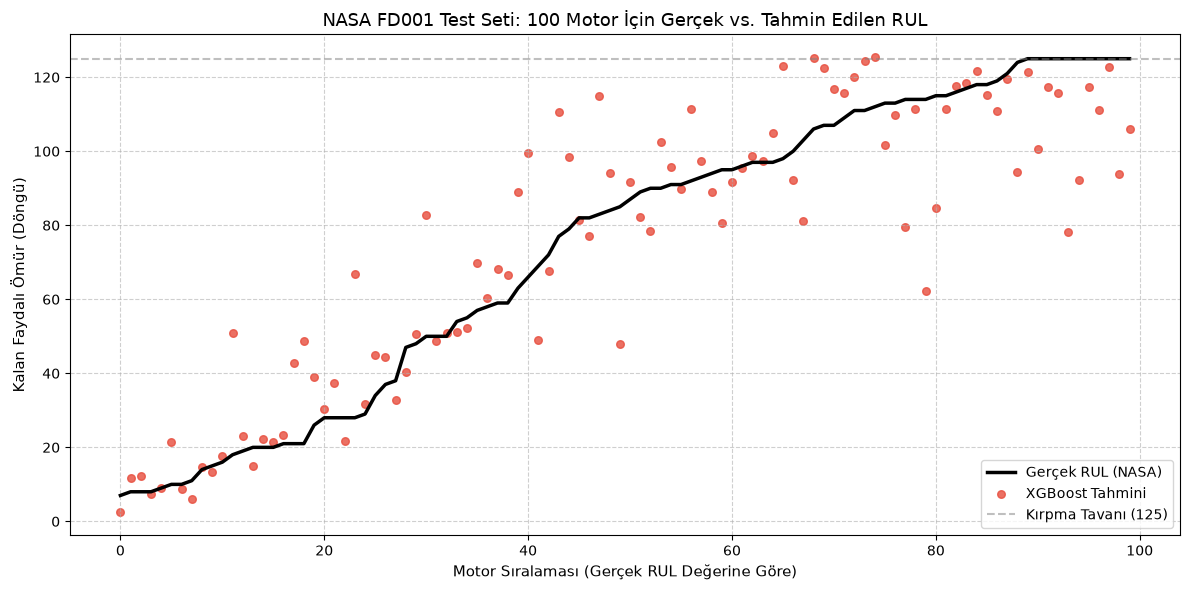

In [26]:
# Motorları gerçek kalan ömürlerine göre küçükten büyüğe sıralayalım
plot_df = pd.DataFrame({
    'true_rul': y_test,
    'pred_rul': y_test_pred
}).sort_values('true_rul').reset_index(drop=True)

plt.figure(figsize=(12, 6))
plt.plot(plot_df['true_rul'], label='Gerçek RUL (NASA)', color='black', linewidth=2.5)
plt.scatter(range(len(plot_df)), plot_df['pred_rul'], label='XGBoost Tahmini', color='#e74c3c', alpha=0.8, s=30)

plt.axhline(y=125, color='gray', linestyle='--', alpha=0.5, label='Kırpma Tavanı (125)')
plt.title("NASA FD001 Test Seti: 100 Motor İçin Gerçek vs. Tahmin Edilen RUL", fontsize=13)
plt.xlabel("Motor Sıralaması (Gerçek RUL Değerine Göre)", fontsize=11)
plt.ylabel("Kalan Faydalı Ömür (Döngü)", fontsize=11)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

In [28]:
with mlflow.start_run(run_name="xgboost_final_test_evaluation"):
    mlflow.log_params(xgb_params)
    mlflow.log_param("windows", "5,20")
    mlflow.log_param("feature_count", len(feature_cols))
    
    # Validation metrikleri
    mlflow.log_metric("val_rmse", 14.47)
    mlflow.log_metric("val_mae", 9.77)
    mlflow.log_metric("val_r2", 0.8796)
    mlflow.log_metric("val_phm_score", 17322.96)
    
    # NASA Resmi Test Metrikleri
    mlflow.log_metric("test_rmse", test_rmse)
    mlflow.log_metric("test_mae", test_mae)
    mlflow.log_metric("test_r2", test_r2)
    mlflow.log_metric("test_phm_score", test_phm)
    
    mlflow.xgboost.log_model(adv_model, name="model")